# Phase 4b — diagnostic workbench: the IC-first engine on Daniocell

A **transparent, read-only workbench** for examining exactly how zlabel's deterministic engine
behaves on the Daniocell broad-tissue benchmark — every success and failure mode, drillable down to
individual clusters, with the engine internals on display (no black boxes).

**The eval in three sentences.** Each Daniocell fine cluster's marker genes go into the engine,
which returns a `Label`: a *named* ZFA term, a coarse *panel fallback*, a germ-layer *rollup*, or an
honest *abstention*. We score **broad agreement** — does the predicted anatomy sit at or under the
gold tissue's ZFA anchor (`grounds_under`)? — and run a **parent-child overcall audit**: when the
engine names a specific term, did it win on the bare minimum genes while a broader term had more
support?

**The engine is not changed here.** This is the measurement leg. Section 6 *previews* how a couple
of fixes would behave (read-only) to inform a later 4c. Run top to bottom.

> Prereqs: the committed `benchmarks/daniocell_eval.csv` (no 2.5 GB download — that is the builder),
> and the `[eval]` extra for pandas (`uv sync --extra eval`). Start the server with `make notebook`
> so the working directory is the repo root.

## 1. Setup — load the benchmark, the crosswalk, and the engine

Everything here reuses the real `zlabel.evaluate` functions (so the notebook can't drift from what
the harness actually does):

- `load_benchmark(csv)` — the benchmark rows (`cluster_id`, `markers`, `broad_tissue`, …).
- `load_crosswalk(yaml)` — the fail-closed `tissue -> broad ZFA anchor(s)` scoring map.
- `load_resources(...)` — the engine's loaded ontologies, panels, and IC model (what a `Labeler`
  holds), so we can label each cluster at its own stage and replay the convergence vote.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import rich
from rich import pretty; pretty.install()
from rich.markdown import Markdown

from zlabel import evaluate
from zlabel.genes import STATUS_RESOLVED, normalize_markers
from zlabel.panels import score_markers
from zlabel.resolve import CONVERGENCE_MIN, resolve_label

# Resolve the repo root whether the kernel started in the repo or the notebook dir.
ROOT = Path.cwd()
while not (ROOT / "benchmarks" / "daniocell_eval.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / "data" / "ontologies"

benchmark = evaluate.load_benchmark(ROOT / "benchmarks" / "daniocell_eval.csv")
crosswalk = evaluate.load_crosswalk(ROOT / "benchmarks" / "daniocell_tissue_crosswalk.yaml")
resources = evaluate.load_resources(
    zfa_path=DATA / "zfa.obo",
    expr_path=DATA / "zfin_wildtype_expression.txt",
    gaf_path=DATA / "zfin.gaf",
    panels_path=ROOT / "src" / "zlabel" / "panels.yaml",
)
print(f"{len(benchmark)} benchmark clusters · {len(resources.panels)} panels · ZFA {resources.zfa_ontology.number_of_nodes():,} terms")

522 benchmark clusters · 14 panels · ZFA 3,161 terms


**What to look for:** 522 clusters, 14 panels, ~3,200 ZFA terms. The benchmark and crosswalk are
small committed files; the resources are the same data a `Labeler` loads.

In [2]:
print("benchmark columns:", ["cluster_id", "markers", "broad_tissue", "tissue_name", "stage_hpf"])
print("example row:", benchmark[0].cluster_id, "| gold tissue:", benchmark[0].broad_tissue,
      "| stage:", benchmark[0].stage_hpf, "| first markers:", benchmark[0].markers[:5])
print("\ncrosswalk (gold tissue -> broad ZFA anchors); 'not_scored' tissues are excluded:")
for t in sorted(crosswalk.anchors)[:6]:
    print(f"  {t}: {sorted(crosswalk.anchors[t])}")
print("  not_scored:", sorted(crosswalk.not_scored))

benchmark columns: ['cluster_id', 'markers', 'broad_tissue', 'tissue_name', 'stage_hpf']
example row: axia.1 | gold tissue: axia | stage: 36.0 | first markers: ['si:ch73-23l24.1', 'col9a1b', 'col2a1a', 'col11a1a', 'col9a2']

crosswalk (gold tissue -> broad ZFA anchors); 'not_scored' tissues are excluded:
  axia: ['ZFA:0001204']
  ceph: ['ZFA:0000113']
  endo: ['ZFA:0000017', 'ZFA:0000339']
  epid: ['ZFA:0000105', 'ZFA:0000368']
  eye: ['ZFA:0000107']
  fin: ['ZFA:0000108']
  not_scored: ['blas']


## 2. The per-cluster outcomes table — the artifact we explore

`cluster_outcomes()` labels and scores **every** cluster and returns one `ClusterOutcome` each
(this is exactly the per-cluster data the headline report aggregates — same numbers, no black box).
We turn it into a DataFrame so we can filter, group, and drill anywhere.

In [3]:
outcomes = evaluate.cluster_outcomes(benchmark, crosswalk, resources)
oc = {o.cluster_id: o for o in outcomes}  # by-id lookup for drill-downs (keeps the full objects)

df = pd.DataFrame([{
    "cluster_id": o.cluster_id,
    "gold_tissue": o.gold_tissue,
    "tissue_name": o.tissue_name,
    "kind": o.kind,                 # named | fallback | rollup | abstain
    "bucket": o.bucket,             # the call (named ZFA term, or coarse panel bucket)
    "panel_bucket": o.panel_bucket, # the coarse prior
    "depth": o.depth,
    "scored": o.scored,             # False for not_scored gold tissues (e.g. blastomeres)
    "agrees": o.agrees,             # True/False for scored named+fallback; None otherwise
    "confidence": o.confidence,
    "abstain_reason": o.abstain_reason,  # no_panel | weak_signal | mixed | None
    "n_resolved": o.n_resolved,     # markers that resolved to a current ZFIN symbol
    "n_convergent": len(o.convergent_genes),
    "support_fraction": o.audit.support_fraction if o.audit else None,
    "thin_overcall": o.audit.thin_support_overcall if o.audit else None,
} for o in outcomes])
print("df:", df.shape)
df.head()

df: (522, 15)


,cluster_id,gold_tissue,tissue_name,kind,bucket,panel_bucket,depth,scored,agrees,confidence,abstain_reason,n_resolved,n_convergent,support_fraction,thin_overcall
0,axia.1,axia,axial,abstain,mixed/unresolved,,0,True,None,None,weak_signal,23,0,NaN,None
1,axia.10,axia,axial,abstain,mixed/unresolved,,0,True,None,None,no_panel,22,0,NaN,None
2,axia.11,axia,axial,abstain,mixed/unresolved,,0,True,None,None,no_panel,22,0,NaN,None
3,axia.12,axia,axial,abstain,mixed/unresolved,,0,True,None,None,mixed,24,0,NaN,None
4,axia.13,axia,axial,abstain,mixed/unresolved,,0,True,None,None,weak_signal,24,0,NaN,None


**Columns to know:** `kind` is how the engine resolved the cluster; `agrees` is broad-tissue
correctness (only meaningful for assigned named/fallback calls); `abstain_reason` decomposes *why*
an abstention happened; `support_fraction`/`thin_overcall` come from the overcall audit on named
calls. Now the headline numbers:

In [4]:

display(Markdown(evaluate.render_report(evaluate.evaluate(benchmark, crosswalk, resources), top_n=8)))

Daniocell baseline report (IC-first engine)                                    

 • clusters: 522  ·  scored: 511  ·  not_scored: 11                                                                

Broad agreement (named + fallback, scored against the gold tissue)                                                 

 • agreement: 53.8% (21/39)                                                                                        

Coverage / split (over scored clusters)                                                                            

 • coverage (non-abstain): 7.6% (39/511)                                                                           
 • named: 1.4% (7/511)                                                                                             
 • fallback: 6.3% (32/511)                                                                                         
 • rollup: 0.0% (0/511)                                                                                            
 • abstain: 92.4% (472/511)                                                                                        

Agreement by prediction class                                                                                      

 • named: 57.1% (4/7)                                                                                              
 • fallback: 53.1% (17/32)                                                                                         

Confidence by correctness (named + fallback)                                                                       

 • high: 80.0% (4/5)                                                                                               
 • medium: 45.8% (11/24)                                                                                           
 • low: 60.0% (6/10)                                                                                               

Parent-child overcall audit (named calls)                                                                          

 • named calls audited: 7                                                                                          
 • won with exactly CONVERGENCE_MIN=3 genes: 85.7% (6/7)                                                           
 • thin-support overcalls (won at min, broader parent had more support): 85.7% (6/7)                               

Lowest support-fraction named calls (child support / best-parent support), top 8:                                  

 • glia.11: trochlear motor nucleus (3) vs brain (22)  -> fraction 0.14                                            
 • neur.30: posterior lateral line placode (3) vs nervous system (21)  -> fraction 0.14                            
 • neur.12: anterior lateral line system (3) vs nervous system (19)  -> fraction 0.16                              
 • neur.33: statoacoustic (VIII) ganglion (3) vs portion of tissue (19)  -> fraction 0.16                          
 • eye.30: statoacoustic (VIII) ganglion (3) vs nervous system (18)  -> fraction 0.17                              
 • peri.6: epidermal superficial stratum (3) vs portion of tissue (16)  -> fraction 0.19                           
 • neur.8: statoacoustic (VIII) ganglion (4) vs portion of tissue (18)  -> fraction 0.22                           

Failure gallery (scored disagreements)                                                                             

 • eye.22: gold eye, predicted 'pigment' (fallback)                                                                
 • eye.30: gold eye, predicted 'statoacoustic (VIII) ganglion' (named)                                             
 • fin.7: gold fin, predicted 'mesenchyme' (fallback)                                                              
 • glia.11: gold glia, predicted 'trochlear motor nucleus' (named)                                                 
 • mura.3: gold mura, predicted 'mesenchyme' (fallback)                      

## 3. How one cluster gets labeled — every stage, nothing hidden

Pick one assigned cluster and walk the full pipeline, printing each stage's output. This is the
mechanism behind every row above: **normalize → score panels → convergence vote → decide → score**.

In [5]:
# Pick a clear example: a named call that still lands in the right broad tissue, else any agreer.
named_ok = [o for o in outcomes if o.kind == "named" and o.agrees]
example = (named_ok or [o for o in outcomes if o.agrees] or outcomes)[0]
row = next(b for b in benchmark if b.cluster_id == example.cluster_id)
print(f"cluster {row.cluster_id}  ·  gold tissue: {row.broad_tissue}  ·  stage: {row.stage_hpf} hpf")
print("raw markers (top 8):", row.markers[:8])

# Stage 1 — normalize every marker to its current ZFIN symbol (aliases/paralogs resolved).
normalized_markers = normalize_markers(row.markers, resources.synonyms)
symbols = [next(iter(normalized_marker.symbols)) for normalized_marker in normalized_markers if normalized_marker.status == STATUS_RESOLVED]
print(f"\n[normalize] {len(symbols)}/{len(row.markers)} markers resolved -> e.g. {symbols[:6]}")

# Stage 2 — score the curated panels (the coarse prior + germ-layer guardrail).
scores = score_markers(normalized_markers, resources.panels)
print("\n[score_markers] top panels:")
for bs in scores[:3]:
    print(f"    {bs.bucket:<16} score={bs.score:.3f}  kind={bs.kind}  matched={[m.symbol for m in bs.matched_markers][:4]}")

# Stage 3 — the IC-weighted convergence vote over ZFIN in-vivo expression (the namer).
votes = resolve_label(symbols, expression_map=resources.expression_map, zfa_ontology=resources.zfa_ontology, information_content=resources.information_content)
print("\n[resolve_label] top candidate ZFA terms (IC-first):")
for vote in votes[:4]:
    print(f"    {vote.zfa_name:<34} IC={vote.information_content:5.2f}  genes={len(vote.genes)}  {sorted(vote.genes)[:4]}")

# Stage 4 + 5 — the decision and the broad-agreement score.
print(f"\n[decide] -> bucket={example.bucket!r}  kind={example.kind}  zfa_id={example.zfa_id}"
      f"  depth={example.depth}  confidence={example.confidence}")
print(f"[score] grounds under gold {row.broad_tissue} anchors {sorted(crosswalk.gold(row.broad_tissue))}?"
      f"  -> agrees={example.agrees}")

cluster neur.12  ·  gold tissue: neur  ·  stage: 48.0 hpf
raw markers (top 8): ['elavl3', 'tuba1c', 'ptmaa', 'nova2', 'hmgb3a', 'stmn1b', 'rtn1a', 'h2afx1']

[normalize] 24/25 markers resolved -> e.g. ['elavl3', 'tuba1c', 'ptmaa', 'nova2', 'hmgb3a', 'stmn1b']

[score_markers] top panels:
    neural           score=0.159  kind=identity  matched=['elavl3', 'tubb5']
    blood_erythroid  score=0.000  kind=identity  matched=[]
    cartilage        score=0.000  kind=identity  matched=[]

[resolve_label] top candidate ZFA terms (IC-first):
    anterior lateral line system       IC= 7.43  genes=3  ['hnrnpaba', 'ptmaa', 'ptmab']
    posterior lateral line ganglion    IC= 7.35  genes=3  ['ckbb', 'elavl3', 'tubb5']
    amacrine cell                      IC= 7.27  genes=3  ['elavl3', 'ptmaa', 'ptmab']
    spinal cord neural tube            IC= 6.88  genes=3  ['elavl3', 'lhx1a', 'tubb5']

[decide] -> bucket='anterior lateral line system'  kind=named  zfa_id=ZFA:0001468  depth=5  confidence=low
[sco

## 4. The success and failure modes

The headline is sobering and honest: the engine **abstains on ~92%** of clusters and is right about
half the time when it commits. Let's see exactly which clusters fall into each mode and why — this
is where fix ideas come from.

In [6]:
print("how the engine resolved each scored cluster:")
scored = df[df["scored"]]
print(scored["kind"].value_counts().to_string())
print(f"\nbroad agreement (named+fallback): "
      f"{scored['agrees'].sum():.0f}/{scored['agrees'].notna().sum()} "
      f"= {100*scored['agrees'].mean():.0f}% of assigned")

how the engine resolved each scored cluster:
kind
abstain     472
fallback     32
named         7

broad agreement (named+fallback): 21/39 = 54% of assigned


### 4a. Abstentions — *why* the engine declined (the bulk)

`abstain_reason` splits the abstentions three ways: **no_panel** (no curated panel matched the
cluster at all), **weak_signal** (a panel matched but below the signal threshold), **mixed** (top
contenders span contradictory germ layers). The split tells us where the ceiling is.

In [7]:
print(df["abstain_reason"].value_counts(dropna=False).to_string())

abstain_reason
weak_signal    290
no_panel       186
None            39
mixed            7


In [8]:
# Panel-coverage ceiling: which gold tissues have NO curated panel that ever scores for them?
cov = []
for t in sorted(crosswalk.anchors):
    sub = df[(df["gold_tissue"] == t) & (df["abstain_reason"].notna())]
    n = (df["gold_tissue"] == t).sum()
    no_panel_rate = (df[(df["gold_tissue"] == t)]["abstain_reason"] == "no_panel").mean()
    cov.append({"tissue": t, "clusters": int(n), "no_panel_rate": round(float(no_panel_rate), 2)})
cov_df = pd.DataFrame(cov).sort_values("no_panel_rate", ascending=False)
print("tissues most starved of a matching panel (no_panel_rate = fraction with zero panel hit):")
cov_df.head(12)

tissues most starved of a matching panel (no_panel_rate = fraction with zero panel hit):


,tissue,clusters,no_panel_rate
1,ceph,1,1.00
17,pron,17,0.88
2,endo,34,0.76
4,eye,41,0.61
10,mura,24,0.46
13,otic,22,0.45
11,musc,36,0.42
18,tast,20,0.40
0,axia,25,0.36
6,glia,31,0.35


**Drill-down:** one `no_panel` abstention (every identity panel scores 0 — there is simply no panel
for this biology) and one `weak_signal` abstention (a panel *does* score, just not enough).

In [9]:
def show_panel_scores(cluster_id, topn=4):
    o = oc[cluster_id]
    row = next(b for b in benchmark if b.cluster_id == cluster_id)
    scores = score_markers(normalize_markers(row.markers, resources.synonyms), resources.panels)
    ident = [s for s in scores if s.kind == "identity"]
    print(f"{cluster_id}  gold={o.gold_tissue}  abstain_reason={o.abstain_reason}")
    print("   top identity panels:", [(s.bucket, round(s.score, 3)) for s in ident[:topn]])

for reason in ("no_panel", "weak_signal"):
    cid = df[df["abstain_reason"] == reason]["cluster_id"].iloc[0]
    show_panel_scores(cid)

axia.10  gold=axia  abstain_reason=no_panel
   top identity panels: [('blood_erythroid', 0.0), ('cartilage', 0.0), ('endoderm_gut', 0.0), ('endothelium', 0.0)]
axia.1  gold=axia  abstain_reason=weak_signal
   top identity panels: [('notochord', 0.132), ('cartilage', 0.066), ('blood_erythroid', 0.0), ('endoderm_gut', 0.0)]


### 4b. Fallback — a panel matched, but the vote named nothing

The cluster scored a panel (so it isn't an abstention), but the convergence vote found no ZFA term
clearing the three gates, so the engine fell back to the coarse panel bucket. These are scored at
the broad level.

In [10]:
fb = df[df["kind"] == "fallback"]
print(f"{len(fb)} fallback clusters · agreement {100*fb['agrees'].mean():.0f}%")
fb[["cluster_id", "gold_tissue", "bucket", "agrees"]].head(10)

32 fallback clusters · agreement 53%


,cluster_id,gold_tissue,bucket,agrees
123,eye.22,eye,pigment,False
169,fin.7,fin,mesenchyme,False
229,hema.33,hema,blood_erythroid,True
231,hema.35,hema,blood_erythroid,True
238,hema.5,hema,blood_erythroid,True
275,mese.19,mese,mesenchyme,True
276,mese.2,mese,mesenchyme,True
277,mese.20,mese,mesenchyme,True
280,mese.23,mese,mesenchyme,True
281,mese.24,mese,mesenchyme,True


### 4c. Named — the few specific calls, and the overcall audit

When the vote *does* name a term, the audit checks for **false precision**: a winner that cleared
exactly `CONVERGENCE_MIN` genes while a broader ancestor had more support. Almost every named call
trips it.

In [11]:
named = [o for o in outcomes if o.kind == "named"]
audit_df = pd.DataFrame([{
    "cluster_id": o.cluster_id, "gold": o.gold_tissue, "named": o.bucket,
    "child_support": o.audit.named_support, "parent": o.audit.parent_name,
    "parent_support": o.audit.parent_support, "support_fraction": round(o.audit.support_fraction, 2),
    "thin_overcall": o.audit.thin_support_overcall, "agrees": o.agrees,
} for o in named])
audit_df.sort_values("support_fraction")

,cluster_id,gold,named,child_support,parent,parent_support,support_fraction,thin_overcall,agrees
1,glia.11,glia,trochlear motor nucleus,3,brain,22,0.14,True,False
3,neur.30,neur,posterior lateral line placode,3,nervous system,21,0.14,True,True
2,neur.12,neur,anterior lateral line system,3,nervous system,19,0.16,True,True
4,neur.33,neur,statoacoustic (VIII) ganglion,3,portion of tissue,19,0.16,True,True
0,eye.30,eye,statoacoustic (VIII) ganglion,3,nervous system,18,0.17,True,False
6,peri.6,peri,epidermal superficial stratum,3,portion of tissue,16,0.19,True,False
5,neur.8,neur,statoacoustic (VIII) ganglion,4,portion of tissue,18,0.22,False,True


In [12]:
# Drill the worst overcall: show the candidate terms it chose among, with IC and gene support.
worst = min(named, key=lambda o: o.audit.support_fraction)
row = next(b for b in benchmark if b.cluster_id == worst.cluster_id)
symbols = [next(iter(normalized_marker.symbols)) for normalized_marker in normalize_markers(row.markers, resources.synonyms) if normalized_marker.status == STATUS_RESOLVED]
votes = resolve_label(symbols, expression_map=resources.expression_map, zfa_ontology=resources.zfa_ontology, information_content=resources.information_content)
print(f"{worst.cluster_id}: engine named {worst.bucket!r} ({worst.audit.named_support} genes) "
      f"over parent {worst.audit.parent_name!r} ({worst.audit.parent_support} genes)\n")
print("the candidates it ranked (IC-first means highest IC wins, regardless of gene support):")
for vote in sorted(votes, key=lambda vote: -vote.information_content)[:6]:
    print(f"    IC={vote.information_content:5.2f}  genes={len(vote.genes):2d}  {vote.zfa_name}")

glia.11: engine named 'trochlear motor nucleus' (3 genes) over parent 'brain' (22 genes)

the candidates it ranked (IC-first means highest IC wins, regardless of gene support):
    IC=11.50  genes= 3  trochlear motor nucleus
    IC=10.65  genes= 3  superior cervical ganglion
    IC=10.24  genes= 3  sympathetic nervous system
    IC=10.12  genes= 3  vagal ganglion 3
    IC=10.01  genes= 3  vagal ganglion 2
    IC=10.01  genes= 3  vagal ganglion 4


### 4d. Right vs wrong (and what the successes share)

Among scored assigned clusters: the disagreements, split into *near-miss* (predicted an adjacent
tissue) vs *cross-tissue* errors, and the successes.

In [13]:
wrong = df[(df["agrees"] == False)]  # noqa: E712  (pandas boolean mask)
right = df[(df["agrees"] == True)]   # noqa: E712
print(f"correct: {len(right)}   wrong: {len(wrong)}\n")
print("disagreements (gold tissue vs predicted bucket):")
print(wrong[["cluster_id", "gold_tissue", "bucket", "kind"]].to_string(index=False))

correct: 21   wrong: 18

disagreements (gold tissue vs predicted bucket):
cluster_id gold_tissue                        bucket     kind
    eye.22         eye                       pigment fallback
    eye.30         eye statoacoustic (VIII) ganglion    named
     fin.7         fin                    mesenchyme fallback
   glia.11        glia       trochlear motor nucleus    named
    mura.3        mura                    mesenchyme fallback
   musc.19        musc                    mesenchyme fallback
   peri.15        peri                     epidermis fallback
   peri.16        peri                     epidermis fallback
   peri.18        peri                     epidermis fallback
   peri.20        peri                     epidermis fallback
   peri.21        peri                     epidermis fallback
   peri.24        peri                     epidermis fallback
   peri.29        peri                     epidermis fallback
    peri.3        peri                     epidermis fallb

## 5. Aggregate diagnostics

Four views of the whole benchmark. Each caption says what to look for.

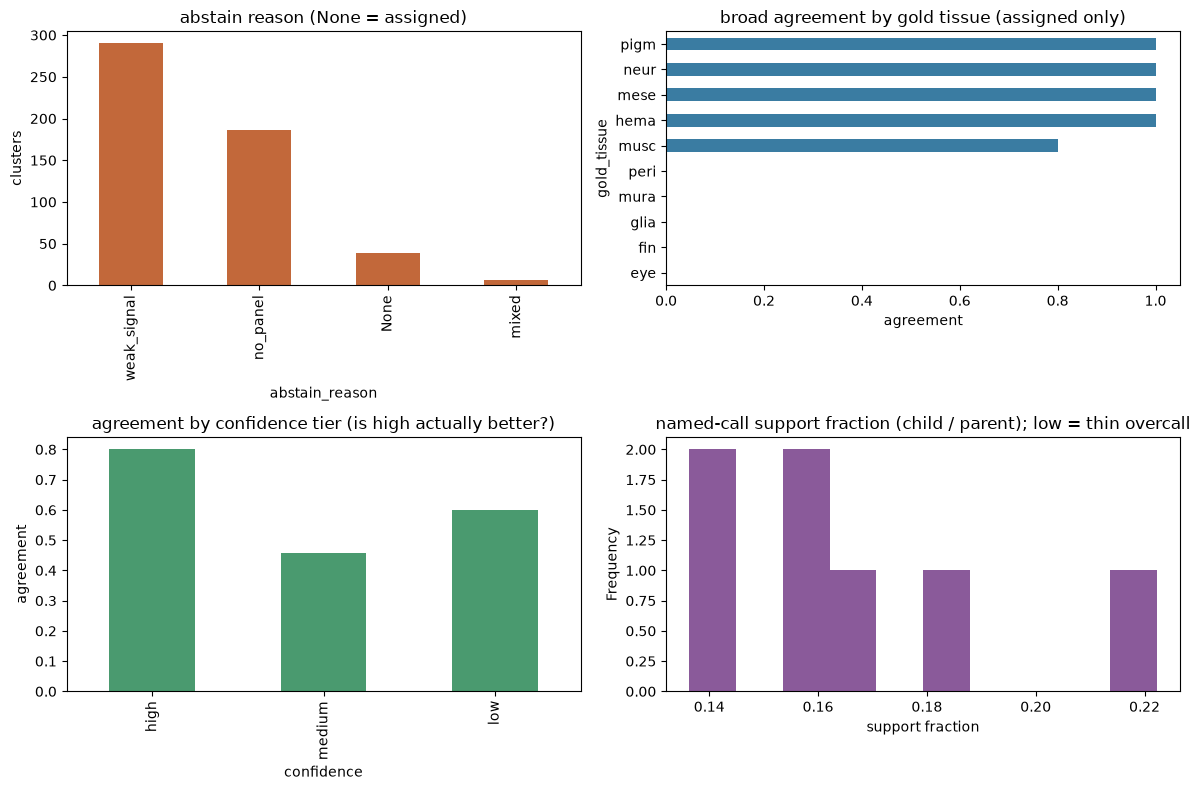

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# (a) abstain reasons
df["abstain_reason"].value_counts(dropna=False).plot.bar(ax=ax[0, 0], color="#c2683a")
ax[0, 0].set_title("abstain reason (None = assigned)")
ax[0, 0].set_ylabel("clusters")

# (b) agreement by tissue (assigned only)
asg = df[df["agrees"].notna()]
by_t = asg.groupby("gold_tissue")["agrees"].agg(["mean", "size"]).sort_values("mean")
by_t["mean"].plot.barh(ax=ax[0, 1], color="#3a7ca2")
ax[0, 1].set_title("broad agreement by gold tissue (assigned only)")
ax[0, 1].set_xlabel("agreement")

# (c) confidence calibration
cal = asg.groupby("confidence")["agrees"].mean().reindex(["high", "medium", "low"])
cal.plot.bar(ax=ax[1, 0], color="#4a9a6f")
ax[1, 0].set_title("agreement by confidence tier (is high actually better?)")
ax[1, 0].set_ylabel("agreement")

# (d) overcall support fraction
df["support_fraction"].dropna().plot.hist(ax=ax[1, 1], bins=10, color="#8a5a9a")
ax[1, 1].set_title("named-call support fraction (child / parent); low = thin overcall")
ax[1, 1].set_xlabel("support fraction")

plt.tight_layout()
plt.show()

**What to look for:** abstentions dominate (coverage ceiling); agreement varies hugely by tissue
(some tissues the panels just can't touch); high confidence *should* sit above medium/low; and the
named-call support fractions cluster low — the IC-first overcall signature.

## 6. Light what-if previews — read-only, engine unchanged

These do **not** change the engine. They recompute, from the candidates the vote already produced,
what an alternative *ranking* would have named — to inform a later 4c (tuning). Two levers:

1. **Support-aware re-rank** — rank candidates by `support_fraction × IC` instead of IC alone, so a
   specific term must also carry consensus to win.
2. **Lower `CONVERGENCE_MIN`** — preview which terms a 2-gene gate would surface (more coverage, but
   does it add noise?).

In [15]:
def what_if_rerank(cluster_id):
    "Read-only: what IC-first names vs a support-aware (support_fraction * IC) re-rank."
    o = oc[cluster_id]
    row = next(b for b in benchmark if b.cluster_id == cluster_id)
    symbols = [next(iter(normalized_marker.symbols)) for normalized_marker in normalize_markers(row.markers, resources.synonyms) if normalized_marker.status == STATUS_RESOLVED]
    votes = resolve_label(symbols, expression_map=resources.expression_map, zfa_ontology=resources.zfa_ontology, information_content=resources.information_content)
    if not votes:
        return None
    max_support = max(len(vote.genes) for vote in votes)
    support_aware = sorted(votes, key=lambda vote: -(len(vote.genes) / max_support) * vote.information_content)
    return {"cluster": cluster_id, "gold": o.gold_tissue,
            "ic_first": votes[0].zfa_name, "support_aware": support_aware[0].zfa_name}

print("support-aware re-rank on the named (overcall-prone) calls:\n")
pd.set_option("display.max_colwidth", 40)
pd.DataFrame([w for o in named if (w := what_if_rerank(o.cluster_id))])

support-aware re-rank on the named (overcall-prone) calls:



,cluster,gold,ic_first,support_aware
0,eye.30,eye,statoacoustic (VIII) ganglion,immature eye
1,glia.11,glia,trochlear motor nucleus,cranial ganglion
2,neur.12,neur,anterior lateral line system,spinal cord
3,neur.30,neur,posterior lateral line placode,cranial ganglion
4,neur.33,neur,statoacoustic (VIII) ganglion,retinal neural layer
5,neur.8,neur,statoacoustic (VIII) ganglion,cranial ganglion
6,peri.6,peri,epidermal superficial stratum,periderm


In [16]:
# Lower-gate preview: how many of today's abstentions have a 2-gene convergent term available?
def best_term_at_min(cluster_id, min_genes):
    row = next(b for b in benchmark if b.cluster_id == cluster_id)
    symbols = [next(iter(normalized_marker.symbols)) for normalized_marker in normalize_markers(row.markers, resources.synonyms) if normalized_marker.status == STATUS_RESOLVED]
    tally = evaluate._replay_tally(symbols, resources.expression_map, resources.zfa_ontology)  # the raw per-term gene tally
    from zlabel.resolve import INFORMATION_CONTENT_MIN, STOPLIST
    cands = [(term_id, len(genes_for_term)) for term_id, genes_for_term in tally.items()
             if len(genes_for_term) >= min_genes and term_id not in STOPLIST and resources.information_content.get(term_id, 0.0) >= INFORMATION_CONTENT_MIN]
    return len(cands)

sample = df[df["abstain_reason"] == "weak_signal"]["cluster_id"].head(20)
gained = sum(best_term_at_min(c, 2) > 0 for c in sample)
print(f"of 20 sampled weak_signal abstentions, {gained} would have a 2-gene convergent term "
      f"(vs the current 3-gene gate). Lever for coverage -- 4c must check it does not add noise.")

of 20 sampled weak_signal abstentions, 20 would have a 2-gene convergent term (vs the current 3-gene gate). Lever for coverage -- 4c must check it does not add noise.


## 7. `inspect()` — poke at any cluster — and the synthesis

`inspect(cluster_id)` prints the full trace for **any** cluster: markers, normalization, panel
scores, the convergence candidates, the decision, the score, and the audit. Use it to explore.

In [17]:
def inspect(cluster_id):
    "Full, transparent trace for one cluster (the poke-around tool)."
    o = oc[cluster_id]
    row = next(b for b in benchmark if b.cluster_id == cluster_id)
    normalized_markers = normalize_markers(row.markers, resources.synonyms)
    symbols = [next(iter(normalized_marker.symbols)) for normalized_marker in normalized_markers if normalized_marker.status == STATUS_RESOLVED]
    scores = [s for s in score_markers(normalized_markers, resources.panels) if s.kind == "identity"]
    votes = resolve_label(symbols, expression_map=resources.expression_map, zfa_ontology=resources.zfa_ontology, information_content=resources.information_content)
    print(f"=== {cluster_id} ===")
    print(f"gold tissue   : {o.gold_tissue}  ({o.tissue_name})   stage {o.stage_hpf} hpf")
    print(f"markers       : {row.markers[:10]}  ({o.n_resolved}/{len(row.markers)} resolved)")
    print(f"top panels    : {[(s.bucket, round(s.score, 3)) for s in scores[:4]]}")
    print(f"vote (IC-first): {[(vote.zfa_name, round(vote.information_content, 2), len(vote.genes)) for vote in votes[:4]] or 'no convergent term'}")
    print(f"decision      : kind={o.kind}  bucket={o.bucket!r}  zfa_id={o.zfa_id}  depth={o.depth}")
    print(f"confidence    : {o.confidence}   abstain_reason={o.abstain_reason}")
    print(f"scored        : agrees={o.agrees}  (gold anchors {sorted(crosswalk.gold(o.gold_tissue)) if o.scored else 'not_scored'})")
    if o.audit:
        a = o.audit
        print(f"overcall audit: named {a.named_support} genes vs parent {a.parent_name!r} {a.parent_support} "
              f"-> fraction {a.support_fraction:.2f}  thin={a.thin_support_overcall}")

inspect(example.cluster_id)
print()
inspect(min(named, key=lambda o: o.audit.support_fraction).cluster_id)

=== neur.12 ===
gold tissue   : neur  (neural)   stage 48.0 hpf
markers       : ['elavl3', 'tuba1c', 'ptmaa', 'nova2', 'hmgb3a', 'stmn1b', 'rtn1a', 'h2afx1', 'marcksl1b', 'tmeff1b']  (24/25 resolved)
top panels    : [('neural', 0.159), ('blood_erythroid', 0.0), ('cartilage', 0.0), ('endoderm_gut', 0.0)]
vote (IC-first): [('anterior lateral line system', 7.43, 3), ('posterior lateral line ganglion', 7.35, 3), ('amacrine cell', 7.27, 3), ('spinal cord neural tube', 6.88, 3)]
decision      : kind=named  bucket='anterior lateral line system'  zfa_id=ZFA:0001468  depth=5
confidence    : low   abstain_reason=None
scored        : agrees=True  (gold anchors ['ZFA:0000396'])
overcall audit: named 3 genes vs parent 'nervous system' 19 -> fraction 0.16  thin=True

=== glia.11 ===
gold tissue   : glia  (glial)   stage 48.0 hpf
markers       : ['elavl3', 'phox2bb', 'rtn1a', 'tmsb', 'marcksl1b', 'tuba1c', 'ptmaa', 'CR383676.1', 'slit3', 'tubb5']  (23/25 resolved)
top panels    : [('neural', 0.171), 

## Synthesis — where the leverage is (questions for the next phase, not answers)

Ordered by how much each would move the numbers:

1. **Panel coverage is the ceiling.** ~36% of clusters get *no* panel hit and another ~56% hit a
   panel too weakly — together ~92% abstention. The 14-panel starter set covers ~12 of Daniocell's
   20 tissues, and even covered tissues' panels are narrow. *Question for 4c: expand/curate panels
   (or learn them from a reference atlas) before anything else?*
2. **IC-first overcalls when it does name.** Almost every named call is a 3-gene hyper-specific term
   beating a broader, better-supported one — and Section 6 showed a support-aware re-rank repairs
   real cases (e.g. an "eye" cluster: IC-first → an ear ganglion; support-aware → "immature eye").
   *Question: is `support_fraction × IC` (or a parent-child margin) the right ranking?*
3. **Conservative abstention is honest, not a bug.** The engine rarely commits wrongly with high
   confidence; it mostly declines. That is the right failure mode for a layer-1 tool — the work is
   to *earn* more confident calls, not to force them.

**What's next — Phase 4c.** Use these measurements to drive panel expansion + a support-aware
ranking, and add a finer-labeled reference (ZSCAPE/Zebrahub) so within-tissue depth can be
*validated*, not just audited. Nothing here changed the engine — 4b measures; 4c tunes.